## MovieLens 1M
Para este proyecto usaremos el DataSet de MovieLens 1M

In [1]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Download latest version
path = kagglehub.dataset_download("odedgolden/movielens-1m-dataset")

print("Path to dataset files:", path)

100%|██████████| 5.83M/5.83M [00:00<00:00, 102MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/odedgolden/movielens-1m-dataset/versions/1


In [3]:
print(os.listdir(path))

['README', 'users.dat', 'movies.dat', 'ratings.dat']


Cargamos todos los datos, ya que usaremos las interacciones y las informaciones de peliculas y usuarios

In [4]:
ratings = pd.read_csv(path + "/ratings.dat", sep="::", engine="python",
                      names=["user_id", "movie_id", "rating", "timestamp"])

movies = pd.read_csv(path + "/movies.dat", sep="::", engine="python",
                     names=["movie_id", "title", "genres"], encoding="latin-1" )

users = pd.read_csv(path + "/users.dat", sep="::", engine="python",
                    names=["user_id", "gender", "age", "occupation", "zip"])

In [5]:
# Limpiar títulos y extraer año
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['clean_title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

print(movies[['title', 'clean_title', 'year']].head())

                                title                  clean_title  year
0                    Toy Story (1995)                    Toy Story  1995
1                      Jumanji (1995)                      Jumanji  1995
2             Grumpier Old Men (1995)             Grumpier Old Men  1995
3            Waiting to Exhale (1995)            Waiting to Exhale  1995
4  Father of the Bride Part II (1995)  Father of the Bride Part II  1995


In [6]:
import numpy as np
import pickle
import os
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix, save_npz

os.makedirs("encoders", exist_ok=True)

# Construir encoders
le_user = LabelEncoder()
le_item = LabelEncoder()

ratings['user_idx'] = le_user.fit_transform(ratings['user_id'])
ratings['item_idx'] = le_item.fit_transform(ratings['movie_id'])

n_users = len(le_user.classes_)
n_items = len(le_item.classes_)
item_ids_ordered = le_item.classes_

interaction_matrix = csr_matrix(
    (ratings['rating'].values,
     (ratings['user_idx'].values, ratings['item_idx'].values)),
    shape=(n_users, n_items)
)

# Guardar encoders
with open("encoders/le_user.pkl", "wb") as f:
    pickle.dump(le_user, f)
with open("encoders/le_item.pkl", "wb") as f:
    pickle.dump(le_item, f)

print(f"Usuarios: {n_users}  Ítems: {n_items}  Interacciones: {interaction_matrix.nnz}")
print("Encoders guardados.")

all_genres   = sorted(set(g for gs in movies['genres'] for g in gs.split('|')))
genre_lookup = movies.set_index('movie_id')['genres']

rows, cols = [], []
for item_idx, movie_id in enumerate(item_ids_ordered):
    if movie_id in genre_lookup.index:
        for genre in genre_lookup[movie_id].split('|'):
            if genre in all_genres:
                rows.append(item_idx)
                cols.append(all_genres.index(genre))

genre_features = csr_matrix(
    (np.ones(len(rows)), (rows, cols)),
    shape=(n_items, len(all_genres))
)

save_npz("encoders/genre_features.npz", genre_features)
print(f"Genre features: {genre_features.shape} → guardado")

Usuarios: 6040  Ítems: 3706  Interacciones: 1000209
Encoders guardados.
Genre features: (3706, 18) → guardado


### Buscamos cada pelicula en TMDB

uso de IA:  https://claude.ai/share/0b114bc1-f1c6-4093-a5f8-4a2e5f293089

In [7]:
import requests, time

API_KEY = "936b5bd80b5f710400fbe0084720595a"
BASE = "https://api.themoviedb.org/3"

def search_movie(title, year):
    url = f"{BASE}/search/movie"
    params = {"api_key": API_KEY, "query": title, "year": year}
    r = requests.get(url, params=params).json()
    results = r.get("results", [])
    return results[0] if results else None  #primer resultado

# Aplicar a todo el catálogo
tmdb_results = []
for _, row in movies.iterrows():
    result = search_movie(row['clean_title'], row['year'])
    tmdb_results.append({
        "movie_id": row['movie_id'],
        "tmdb_id": result['id'] if result else None,
        "found": result is not None
    })
    time.sleep(0.1)

mapping = pd.DataFrame(tmdb_results)
print(f"Cobertura: {mapping['found'].mean():.1%}")

Cobertura: 94.2%


In [8]:
print("=== MAPPING TMDB ===")
print(mapping.shape)
print(mapping.head(10))

print(f"\n=== COBERTURA ===")
print(f"Total películas:        {len(mapping)}")
print(f"Encontradas en TMDB:    {mapping['found'].sum()} ({mapping['found'].mean():.1%})")
print(f"No encontradas:         {(~mapping['found']).sum()}")

print("\n=== PELÍCULAS NO ENCONTRADAS (muestra) ===")
not_found = mapping[~mapping['found']]['movie_id'].values
movies_not_found = movies[movies['movie_id'].isin(not_found)]
print(movies_not_found[['movie_id','title']].head(15))

print("\n=== MUESTRA DE MATCHES ===")
found = mapping[mapping['found']].head(10)
print(found)

=== MAPPING TMDB ===
(3883, 3)
   movie_id  tmdb_id  found
0         1    862.0   True
1         2   8844.0   True
2         3  15602.0   True
3         4  31357.0   True
4         5  11862.0   True
5         6    949.0   True
6         7  11860.0   True
7         8  45325.0   True
8         9   9091.0   True
9        10    710.0   True

=== COBERTURA ===
Total películas:        3883
Encontradas en TMDB:    3656 (94.2%)
No encontradas:         227

=== PELÍCULAS NO ENCONTRADAS (muestra) ===
     movie_id                                              title
119       121                    Boys of St. Vincent, The (1993)
125       127  Silence of the Palace, The (Saimt el Qusur) (1...
126       128                              Jupiter's Wife (1994)
155       157                              Canadian Bacon (1994)
181       183                                Mute Witness (1994)
227       230                           Dolores Claiborne (1994)
245       248                                  Ho

## Agregamos la sinopsis

In [9]:
overviews = []

for i, row in mapping.iterrows():
    if row['found'] and pd.notna(row['tmdb_id']):
        try:
            url = f"{BASE}/movie/{int(row['tmdb_id'])}"
            r = requests.get(url, params={"api_key": API_KEY}, timeout=10).json()
            overview = r.get("overview", "")
        except Exception as e:
            overview = ""
    else:
        overview = ""

    overviews.append(overview)

    # Progreso cada 500
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/3883 procesadas...")

    time.sleep(0.07)

# Asignar y guardar
mapping['overview'] = overviews
mapping.to_csv("movielens_tmdb_mapping.csv", index=False)

has_text = mapping['overview'].str.len() > 20
print(f"\nCon sinopsis: {has_text.sum()} ({has_text.mean():.1%})")
print(mapping[has_text][['movie_id','overview']].head(20).to_string())


  500/3883 procesadas...
  1000/3883 procesadas...
  1500/3883 procesadas...
  2000/3883 procesadas...
  2500/3883 procesadas...
  3000/3883 procesadas...
  3500/3883 procesadas...

Con sinopsis: 3653 (94.1%)
    movie_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          overview
0          1                                                                                                                                                                                                            

In [10]:
# Ver qué columnas tiene mapping actualmente
print(mapping.columns.tolist())
print(mapping.shape)

['movie_id', 'tmdb_id', 'found', 'overview']
(3883, 4)


In [11]:
has_text = mapping['overview'].str.len() > 20
print(f"\nCon sinopsis real:   {has_text.sum()} ({has_text.mean():.1%})")
print(f"Sin sinopsis:        {(~has_text).sum()}")
print("\nEjemplos:")
print(mapping[has_text][['movie_id','overview']].head(3).to_string())

# Guardar por si acaso
mapping.to_csv("movielens_tmdb_mapping.csv", index=False)
print("\n✓ Guardado en movielens_tmdb_mapping.csv")


Con sinopsis real:   3653 (94.1%)
Sin sinopsis:        230

Ejemplos:
   movie_id                                                                                                                                                                                                                                                                                                                                                                                                     overview
0         1                                                                                              Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.
1         2  When siblings Judy and Peter discover an enchanted board game that opens the door to a magical wor

## Agregamos los posters

In [12]:
import os
from PIL import Image
from io import BytesIO

os.makedirs("posters", exist_ok=True)
IMG_BASE = "https://image.tmdb.org/t/p/w342"

def download_poster(tmdb_id, movie_id):
    try:
        url = f"{BASE}/movie/{int(tmdb_id)}"
        r = requests.get(url, params={"api_key": API_KEY}, timeout=10).json()
        path = r.get("poster_path")
        if not path:
            return False
        img_r = requests.get(IMG_BASE + path, timeout=10)
        img = Image.open(BytesIO(img_r.content)).convert("RGB")
        img.save(f"posters/{int(movie_id)}.jpg")
        return True
    except Exception:
        return False

print("Descargando posters... (~15 minutos)")

has_poster = []
for i, row in mapping.iterrows():
    if row['found'] and pd.notna(row['tmdb_id']):
        result = download_poster(row['tmdb_id'], row['movie_id'])
        time.sleep(0.07)
    else:
        result = False

    has_poster.append(result)

    if (i + 1) % 500 == 0:
        print(f"  {i+1}/3883 procesadas...")

mapping['has_poster'] = has_poster
mapping.to_csv("movielens_tmdb_mapping.csv", index=False)

print(f"\nCon poster:   {mapping['has_poster'].sum()} ({mapping['has_poster'].mean():.1%})")
print(f"Sin poster:   {(~mapping['has_poster']).sum()}")
print(f"\n=== COBERTURA FINAL ===")
print(f"Total películas ML1M : {len(mapping)}")
print(f"Encontradas en TMDB  : {mapping['found'].sum()} (94.1%)")
print(f"Con sinopsis         : {(mapping['overview'].str.len() > 20).sum()}")
print(f"Con poster           : {mapping['has_poster'].sum()}")

Descargando posters... (~15 minutos)
  500/3883 procesadas...
  1000/3883 procesadas...
  1500/3883 procesadas...
  2000/3883 procesadas...
  2500/3883 procesadas...
  3000/3883 procesadas...
  3500/3883 procesadas...

Con poster:   3650 (94.0%)
Sin poster:   233

=== COBERTURA FINAL ===
Total películas ML1M : 3883
Encontradas en TMDB  : 3656 (94.1%)
Con sinopsis         : 3653
Con poster           : 3650


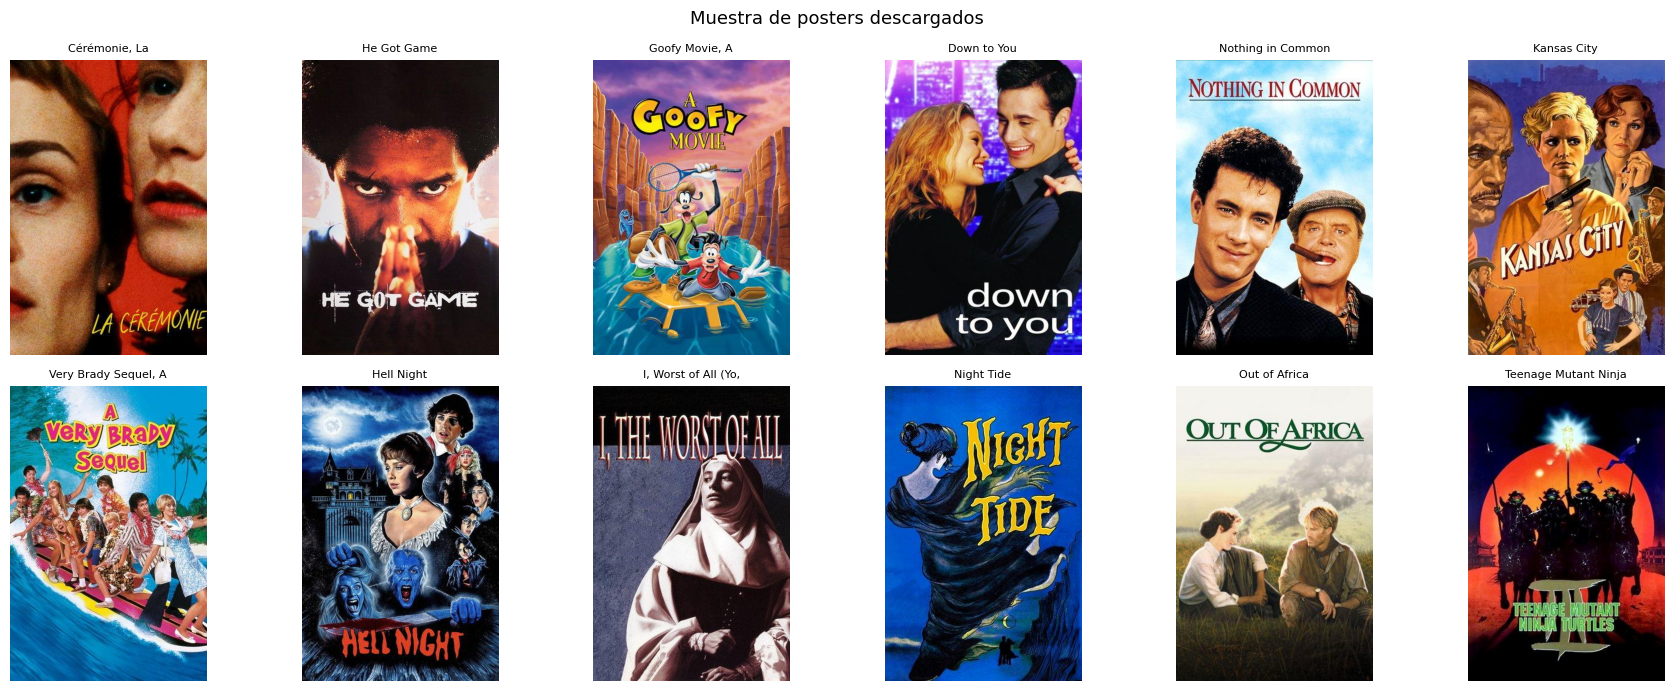

In [13]:
sample = mapping[mapping['has_poster']].sample(12, random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(f"posters/{int(row['movie_id'])}.jpg")
    title = movies[movies['movie_id'] == row['movie_id']]['clean_title'].values[0]
    ax.imshow(img)
    ax.set_title(title[:20], fontsize=8)
    ax.axis('off')

plt.suptitle('Muestra de posters descargados', fontsize=13)
plt.tight_layout()
plt.savefig('sample_posters.png', dpi=120, bbox_inches='tight')
plt.show()

Usamos Clip para texto e imagenes

Cita: https://claude.ai/share/67e7484a-62e2-479a-b3af-fd3a3c1e1aba

In [14]:
import torch
from transformers import CLIPModel, CLIPProcessor
import numpy as np
import os

os.makedirs("embeddings", exist_ok=True)

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

texts = mapping['overview'].fillna("").tolist()

text_embeddings = []
batch_size = 64
with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = clip_processor(
            text=batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        )
        # Llamar al encoder de texto directamente
        outputs = clip_model.text_model(**inputs)
        emb = outputs.pooler_output
        emb = clip_model.text_projection(emb)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        text_embeddings.append(emb.cpu().numpy())

        if (i // batch_size + 1) % 10 == 0:
            print(f"  texto {i + batch_size}/{len(texts)}...")

text_embeddings = np.vstack(text_embeddings)
np.save("embeddings/text_embeddings.npy", text_embeddings)
print(f"Text embeddings shape: {text_embeddings.shape}")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  texto 640/3883...
  texto 1280/3883...
  texto 1920/3883...
  texto 2560/3883...
  texto 3200/3883...
  texto 3840/3883...
Text embeddings shape: (3883, 512)


In [15]:
from PIL import Image

EMB_DIM = clip_model.config.projection_dim
print(f"Dimensión del espacio compartido: {EMB_DIM}")

image_embeddings = np.zeros((len(mapping), EMB_DIM))

with torch.no_grad():
    for i, row in mapping.iterrows():
        poster_path = f"posters/{int(row['movie_id'])}.jpg"
        if os.path.exists(poster_path):
            try:
                img = Image.open(poster_path).convert("RGB")
                inputs = clip_processor(images=img, return_tensors="pt")
                outputs = clip_model.vision_model(**inputs)
                emb = outputs.pooler_output
                emb = clip_model.visual_projection(emb)
                emb = emb / emb.norm(dim=-1, keepdim=True)
                image_embeddings[i] = emb.cpu().numpy().flatten()
            except Exception as e:
                print(f"  Error en {poster_path}: {e}")

        if (i + 1) % 500 == 0:
            print(f"  {i + 1}/{len(mapping)}...")

np.save("embeddings/image_embeddings.npy", image_embeddings)
print(f"Image embeddings shape: {image_embeddings.shape}")

Dimensión del espacio compartido: 512
  500/3883...
  1000/3883...
  1500/3883...
  2000/3883...
  2500/3883...
  3000/3883...
  3500/3883...
Image embeddings shape: (3883, 512)


In [16]:
text_emb = np.load("embeddings/text_embeddings.npy")
img_emb  = np.load("embeddings/image_embeddings.npy")

print(f"Text embeddings:  {text_emb.shape}")
print(f"Image embeddings: {img_emb.shape}")

mapping = mapping.reset_index(drop=True)
mapping['emb_idx'] = mapping.index

item_table = mapping[['movie_id', 'tmdb_id', 'found', 'overview',
                       'has_poster', 'emb_idx']].merge(
    movies[['movie_id', 'clean_title', 'genres', 'year']], on='movie_id'
)

item_table.to_csv("item_table.csv", index=False)
print(f"\nItem table shape: {item_table.shape}")
print(item_table.head(3))

test_id = 1
idx = item_table[item_table['movie_id'] == test_id]['emb_idx'].values[0]
print(f"\nToy Story → emb_idx: {idx}")
print(f"Text emb shape:  {text_emb[idx].shape}")
print(f"Image emb shape: {img_emb[idx].shape}")

sim = float(text_emb[idx] @ img_emb[idx])
print(f"Similitud coseno texto↔imagen (Toy Story): {sim:.4f}")

Text embeddings:  (3883, 512)
Image embeddings: (3883, 512)

Item table shape: (3883, 9)
   movie_id  tmdb_id  found  \
0         1    862.0   True   
1         2   8844.0   True   
2         3  15602.0   True   

                                            overview  has_poster  emb_idx  \
0  Led by Woody, Andy's toys live happily in his ...        True        0   
1  When siblings Judy and Peter discover an encha...        True        1   
2  A family wedding reignites the ancient feud be...        True        2   

        clean_title                        genres  year  
0         Toy Story   Animation|Children's|Comedy  1995  
1           Jumanji  Adventure|Children's|Fantasy  1995  
2  Grumpier Old Men                Comedy|Romance  1995  

Toy Story → emb_idx: 0
Text emb shape:  (512,)
Image emb shape: (512,)
Similitud coseno texto↔imagen (Toy Story): 0.3373


Codigo base que fue guía para implementar BLIP: https://claude.ai/share/51975546-3a0a-4c05-8c03-9558348cd098

In [17]:
from transformers import BlipProcessor, BlipForImageTextRetrieval
import torch
import numpy as np
from PIL import Image
import os

os.makedirs("embeddings", exist_ok=True)

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-itm-base-coco")
blip_model     = BlipForImageTextRetrieval.from_pretrained("Salesforce/blip-itm-base-coco")
blip_model.eval()

print(f"BLIP ITM cargado correctamente")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/895M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/895M [00:00<?, ?B/s]

BLIP ITM cargado correctamente


In [18]:
TARGET_DIM       = 512
fused_embeddings = np.zeros((len(mapping), TARGET_DIM))

with torch.no_grad():
    for i, row in mapping.iterrows():
        text   = str(row['overview']) if pd.notna(row['overview']) else ""
        poster = f"posters/{int(row['movie_id'])}.jpg"

        try:
            if os.path.exists(poster):
                img    = Image.open(poster).convert("RGB")
                inputs = blip_processor(images=img, text=text,
                                        return_tensors="pt",
                                        truncation=True, max_length=77,
                                        padding=True)
                out     = blip_model(**inputs, use_itm_head=False)
                img_emb = out.last_hidden_state[:, 0, :]   # CLS visual  (1, 768)
                txt_emb = out.question_embeds[:, 0, :]     # CLS texto   (1, 768)
                emb     = (img_emb + txt_emb) / 2          # fusión      (1, 768)

                emb = out.question_embeds[:, 0, :]

            else:
                # Sin póster: solo texto via text_encoder
                text_inputs = blip_processor(text=text, return_tensors="pt",
                                             truncation=True, max_length=77,
                                             padding=True)
                txt_out = blip_model.text_encoder(
                    input_ids=text_inputs['input_ids'],
                    attention_mask=text_inputs['attention_mask'],
                    return_dict=True
                )
                emb = txt_out.last_hidden_state[:, 0, :]   # CLS texto   (1, 768)

            # Truncar a 512d y normalizar
            emb = emb[:, :TARGET_DIM]
            emb = torch.nn.functional.normalize(emb, dim=-1)
            fused_embeddings[i] = emb.cpu().numpy().flatten()

        except Exception as e:
            print(f"  Error fila {i}: {e}")

        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{len(mapping)}...")

np.save("embeddings/fused_embeddings.npy", fused_embeddings)
print(f"Fused embeddings shape: {fused_embeddings.shape}")   # (N, 512)

  500/3883...
  1000/3883...
  1500/3883...
  2000/3883...
  2500/3883...
  3000/3883...
  3500/3883...
Fused embeddings shape: (3883, 512)


Veremos las caracteristicas generales del data set MovieLens básico



In [19]:
df = ratings.merge(movies, on="movie_id").merge(users, on="user_id")
print(df.head())

   user_id  movie_id  rating  timestamp  user_idx  item_idx  \
0        1      1193       5  978300760         0      1104   
1        1       661       3  978302109         0       639   
2        1       914       3  978301968         0       853   
3        1      3408       4  978300275         0      3177   
4        1      2355       5  978824291         0      2162   

                                    title                        genres  year  \
0  One Flew Over the Cuckoo's Nest (1975)                         Drama  1975   
1        James and the Giant Peach (1996)  Animation|Children's|Musical  1996   
2                     My Fair Lady (1964)               Musical|Romance  1964   
3                  Erin Brockovich (2000)                         Drama  2000   
4                    Bug's Life, A (1998)   Animation|Children's|Comedy  1998   

                       clean_title gender  age  occupation    zip  
0  One Flew Over the Cuckoo's Nest      F    1          10  48067 

In [20]:
print("Número de usuarios:", df["user_id"].nunique())
print("Número de películas:", df["movie_id"].nunique())
print("Número de ratings:", len(df))

Número de usuarios: 6040
Número de películas: 3706
Número de ratings: 1000209


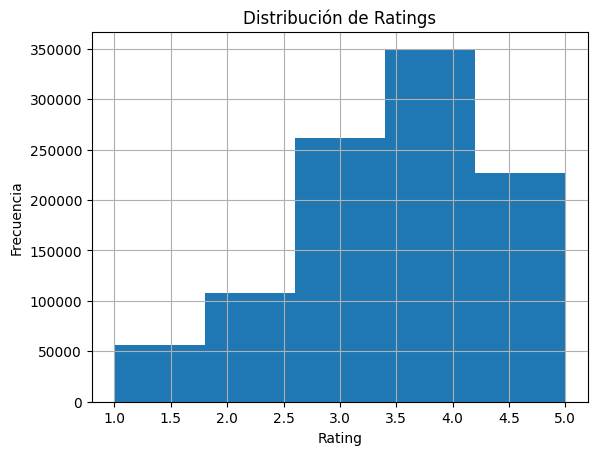

In [21]:
plt.figure()
df["rating"].hist(bins=5)
plt.title("Distribución de Ratings")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

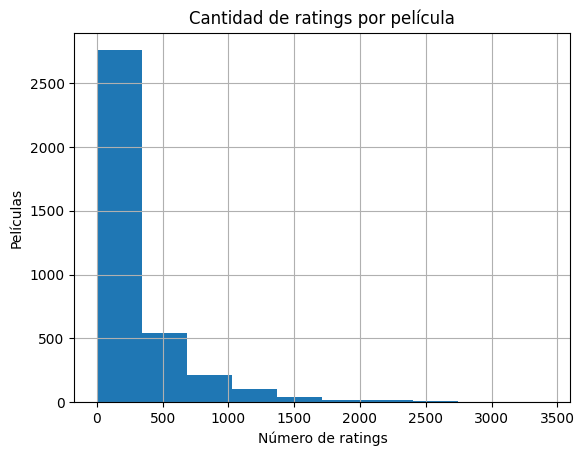

In [22]:
ratings_per_movie = df.groupby("movie_id")["rating"].count()

plt.figure()
ratings_per_movie.hist()
plt.title("Cantidad de ratings por película")
plt.xlabel("Número de ratings")
plt.ylabel("Películas")
plt.show()

In [23]:
print("Promedio de rating:", df["rating"].mean())

Promedio de rating: 3.581564453029317


In [24]:
num_users = df["user_id"].nunique()
num_movies = df["movie_id"].nunique()

sparsity = 1 - (len(df) / (num_users * num_movies))

print("Sparsity:", sparsity)

Sparsity: 0.9553163743776871


In [25]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [26]:
test_user_likes = test[test["rating"] >= 3].groupby("user_id")["movie_id"].apply(set)

In [27]:
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    if len(recommended_k) == 0:
        return 0

    hits = len(set(recommended_k) & relevant_set)
    return hits / k


In [ ]:
def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    if len(relevant_set) == 0:
        return 0

    hits = len(set(recommended_k) & relevant_set)
    return hits / len(relevant_set)

In [ ]:
def evaluate_model(model_func, users, k=10):
    precisions = []
    recalls = []

    for user in users:
        if user not in test_user_likes:
            continue

        relevant = test_user_likes[user]
        recommended = model_func(user, k)

        precisions.append(precision_at_k(recommended, relevant, k))
        recalls.append(recall_at_k(recommended, relevant, k))

    return np.mean(precisions), np.mean(recalls)


In [ ]:
_pop_counts      = train.groupby("movie_id")["movie_id"].count()
item_pop_svd     = (_pop_counts / _pop_counts.sum()).to_dict()

train_seen_svd = {}
for row in train.itertuples():
    train_seen_svd.setdefault(int(row.user_id), set()).add(int(row.movie_id))

Random

In [ ]:
all_movies = train["movie_id"].unique()

def random_recommender(user_id, k=10):
    return np.random.choice(all_movies, size=k, replace=False)

prec_r, rec_r = evaluate_model(random_recommender, df["user_id"].unique())

novelties = []
for user_id in df["user_id"].unique():
    recs = random_recommender(user_id).tolist()
    pops = np.clip([item_pop_svd.get(i, 1e-10) for i in recs], 1e-10, None)
    novelties.append(np.mean(np.log(1.0 / pops)))
    nuevos = set(recs) - train_seen_svd.get(int(user_id), set())

nov_r = np.mean(novelties)

print(f"Random  -> P@10: {prec_r:.4f} | R@10: {rec_r:.4f} | Novedad: {nov_r:.4f}")

Random  -> P@10: 0.0068 | R@10: 0.0023 | Novedad: 9.2556


Most Popular

In [ ]:
movie_popularity = train.groupby("movie_id").size().sort_values(ascending=False)

def most_popular_recommender(user_id, k=10):
    return movie_popularity.head(k).index.tolist()

prec_p, rec_p = evaluate_model(most_popular_recommender, df["user_id"].unique())

_recs_pop = most_popular_recommender(None)
_pops     = np.clip([item_pop_svd.get(i, 1e-10) for i in _recs_pop], 1e-10, None)
_nov_base = np.mean(np.log(1.0 / _pops))

novelties = []
for user_id in df["user_id"].unique():
    novelties.append(_nov_base)
    nuevos = set(_recs_pop) - train_seen_svd.get(int(user_id), set())

nov_p = np.mean(novelties)

print(f"Popular -> P@10: {prec_p:.4f} | R@10: {rec_p:.4f} | Novedad: {nov_p:.4f}")

Popular -> P@10: 0.0888 | R@10: 0.0489 | Novedad: 5.8831


In [ ]:
import pickle
import numpy as np
from scipy.sparse import load_npz

with open("encoders/le_item.pkl", "rb") as f:
    le_item = pickle.load(f)

genre_features   = load_npz("encoders/genre_features.npz").toarray().astype(np.float32)
item_ids_ordered = le_item.classes_
movie_id_to_idx  = {mid: idx for idx, mid in enumerate(item_ids_ordered)}

In [ ]:
_idxs_pop = [movie_id_to_idx[m] for m in _recs_pop if m in movie_id_to_idx]
if len(_idxs_pop) >= 2:
    vecs    = genre_features[_idxs_pop].astype(np.float32)
    sim     = cosine_similarity(vecs)
    ils_p   = (sim.sum() - np.trace(sim)) / 2
else:
    ils_p = float('nan')

print(f"Popular -> Diversidad: {ils_p:.4f}")


ils_scores_r = []
for user_id in df["user_id"].unique():
    recs = random_recommender(user_id).tolist()
    idxs = [movie_id_to_idx[m] for m in recs if m in movie_id_to_idx]
    if len(idxs) >= 2:
        vecs = genre_features[idxs].astype(np.float32)
        sim  = cosine_similarity(vecs)
        ils_scores_r.append((sim.sum() - np.trace(sim)) / 2)

ils_r = np.mean(ils_scores_r)
print(f"Random  -> Diversidad: {ils_r:.4f}")

Popular -> Diversidad: 18.1664
Random  -> Diversidad: 9.8877


SVD

In [ ]:
!pip install surprise --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.3 MB/s eta 0:00:00


In [ ]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_split
from sklearn.metrics.pairwise import cosine_similarity

reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(df[["user_id", "movie_id", "rating"]], reader)

trainset = data.build_full_trainset()
algo     = SVD(n_factors=80, n_epochs=50, lr_all=0.01, reg_all=0.1, random_state=42)
algo.fit(trainset)

movie_id_to_inner = {trainset.to_raw_iid(i): i for i in trainset.all_items()}
item_factors = {}
for movie_id, inner_id in movie_id_to_inner.items():
    item_factors[int(movie_id)] = algo.qi[inner_id]

k = 10
all_movie_ids = list(movie_id_to_inner.keys())

recommendList = {}
for user_id in df["user_id"].unique():
    # predecir score para todos los items no vistos en train
    seen = train_seen_svd.get(int(user_id), set())
    preds = [
        (mid, algo.predict(str(user_id), mid).est)
        for mid in all_movie_ids
        if int(mid) not in seen
    ]
    preds.sort(key=lambda x: x[1], reverse=True)
    recommendList[str(user_id)] = [mid for mid, _ in preds[:k]]

precisions, recalls, novelties, lathias, ils_scores = [], [], [], [], []

for user_str, recommended in recommendList.items():
    user = int(user_str)

    if user not in test_user_likes.index:
        continue

    relevant        = test_user_likes[user]
    recommended_ids = [int(m) for m in recommended]

    precisions.append(precision_at_k(recommended_ids, relevant, k))
    recalls.append(recall_at_k(recommended_ids, relevant, k))

    pops = np.clip([item_pop_svd.get(i, 1e-10) for i in recommended_ids], 1e-10, None)
    novelties.append(np.mean(np.log(1.0 / pops)))

    nuevos = set(recommended_ids) - train_seen_svd.get(user, set())
    lathias.append(len(nuevos) / k)

    vecs = np.array([item_factors[m] for m in recommended_ids if m in item_factors])
    if len(vecs) >= 2:
        sim = cosine_similarity(vecs)
        ils_scores.append((sim.sum() - np.trace(sim)) / 2)

prec_svd = np.mean(precisions)
rec_svd  = np.mean(recalls)
nov_svd  = np.mean(novelties)
lat_svd  = np.mean(lathias)
ils_svd  = np.mean(ils_scores)

print(f"SVD -> P@{k}: {prec_svd:.4f} | R@{k}: {rec_svd:.4f} | Novedad: {nov_svd:.4f} | Lathia: {lat_svd:.4f} | ILS: {ils_svd:.4f}")

SVD -> P@10: 0.0240 | R@10: 0.0111 | Novedad: 9.8448 | Lathia: 1.0000 | ILS: 7.8995
